In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("social media .csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  str    
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  str    
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  str    
 5   content_category          29999 non-null  str    
 6   traffic_source            29999 non-null  str    
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  str    
 9   post_date                 29999 non-null  str    
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  str    
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares           

In [6]:
df = df.drop(columns=['post_id'], errors='ignore')

In [7]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])
df['post_date'] = pd.to_datetime(df['post_date'])

In [8]:
df['month'] = df['post_datetime'].dt.month
df['day'] = df['post_datetime'].dt.day

In [9]:
import seaborn as sns
from matplotlib.pyplot import show

account_id


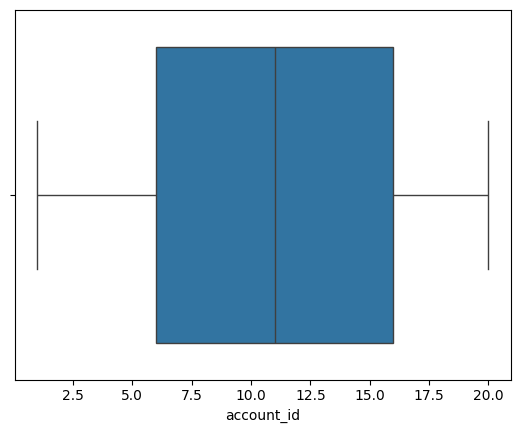

****************************************************************************************


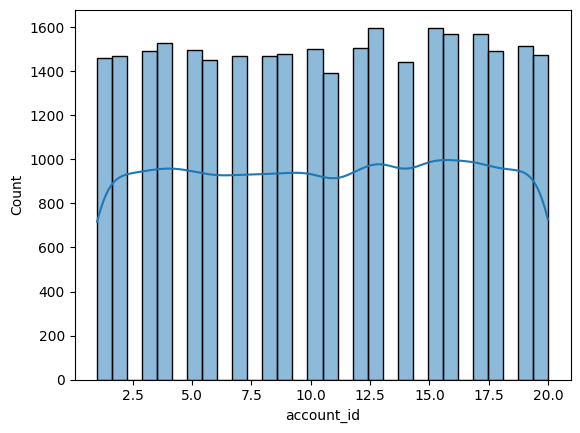

account_type


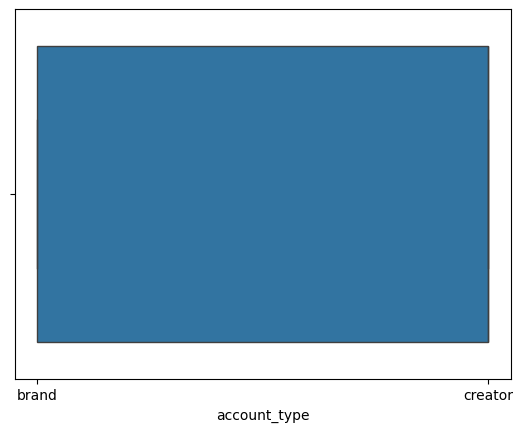

****************************************************************************************


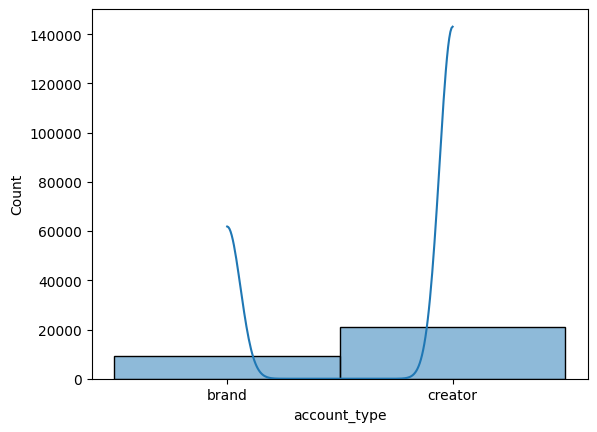

follower_count


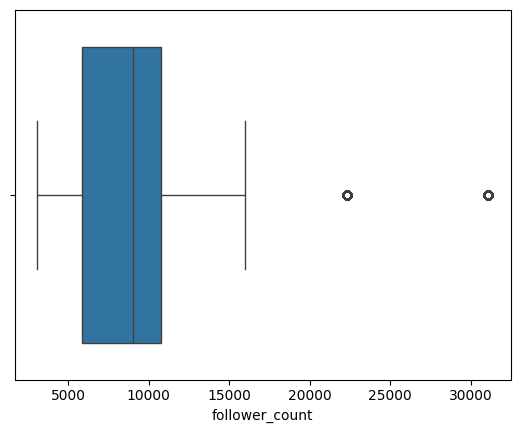

****************************************************************************************


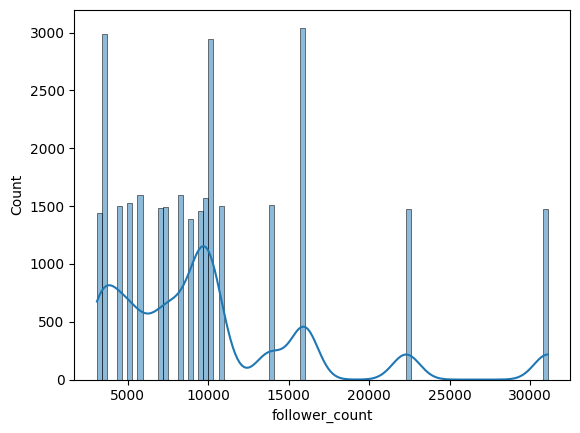

media_type


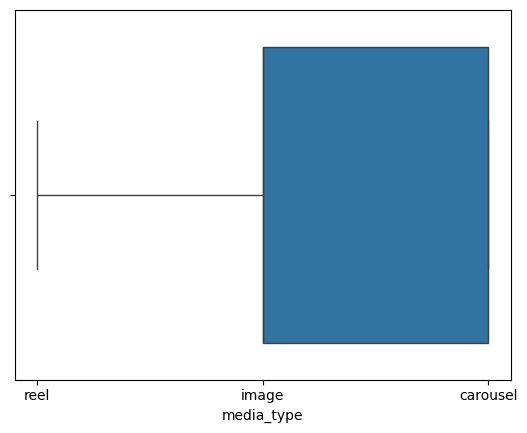

****************************************************************************************


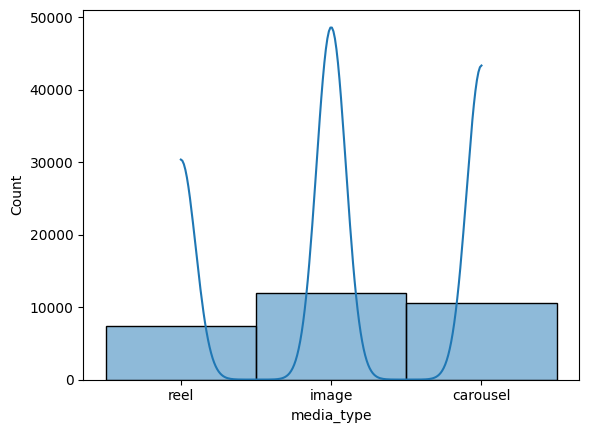

content_category


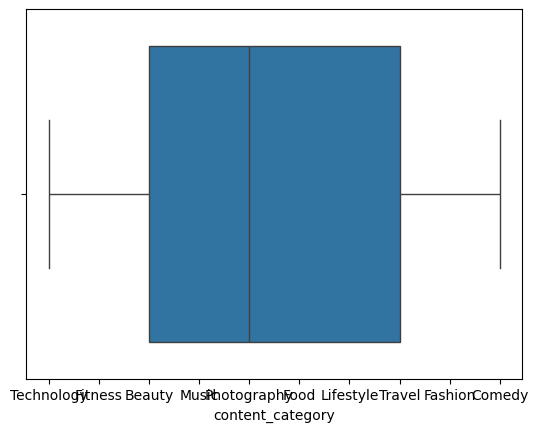

****************************************************************************************


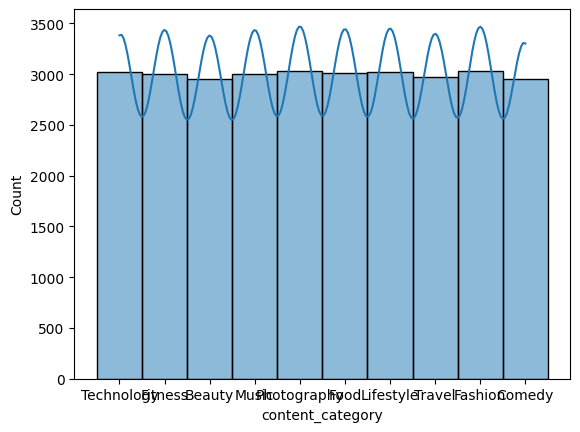

traffic_source


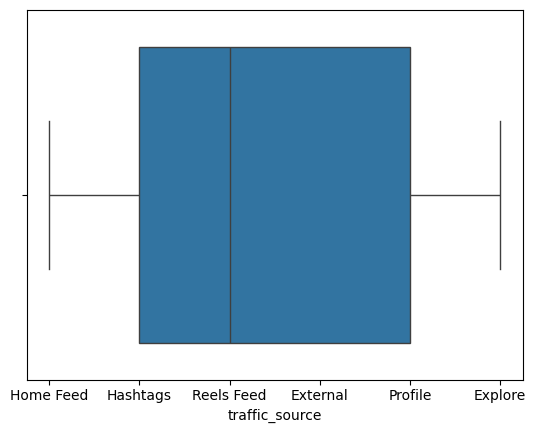

****************************************************************************************


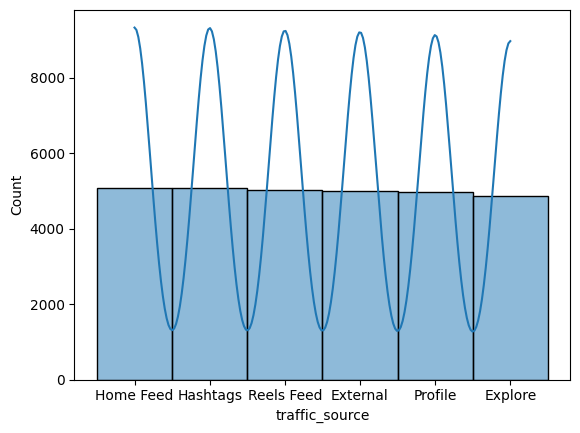

has_call_to_action


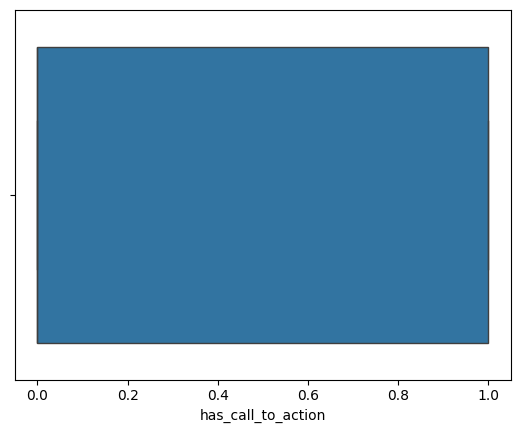

****************************************************************************************


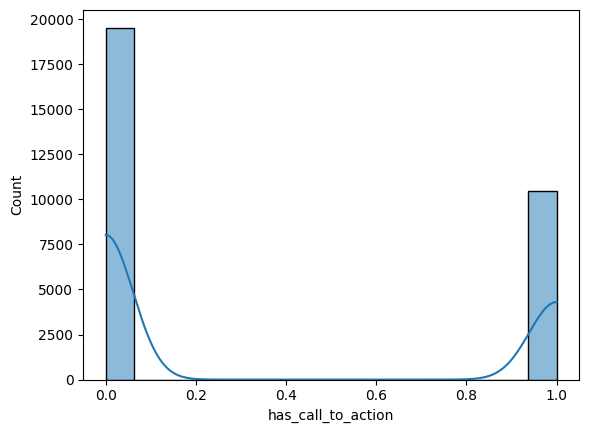

post_datetime


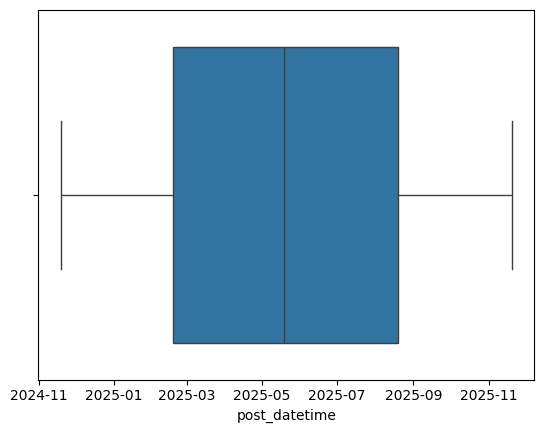

****************************************************************************************


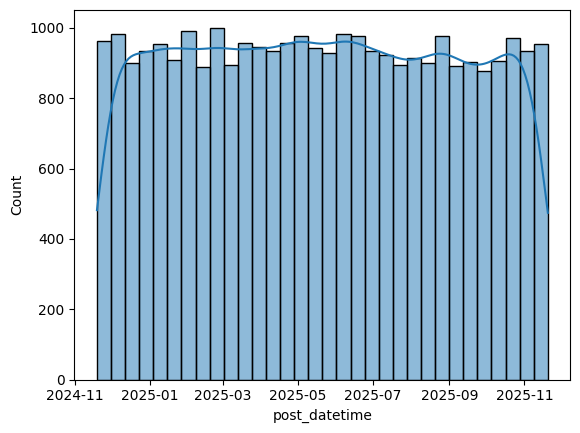

post_date


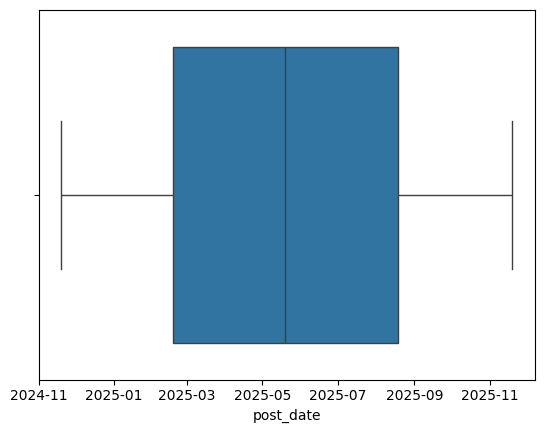

****************************************************************************************


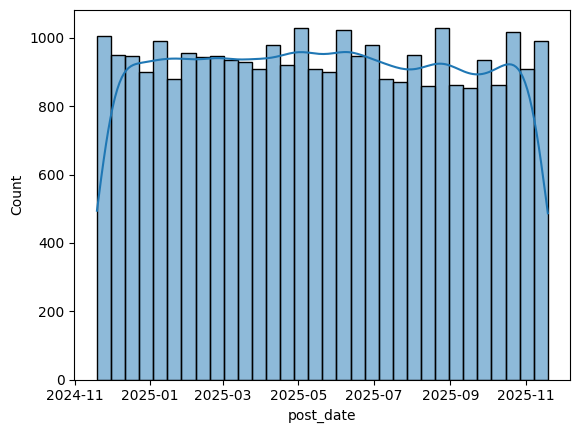

post_hour


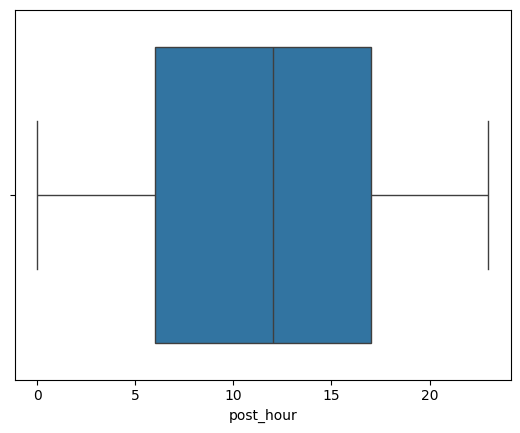

****************************************************************************************


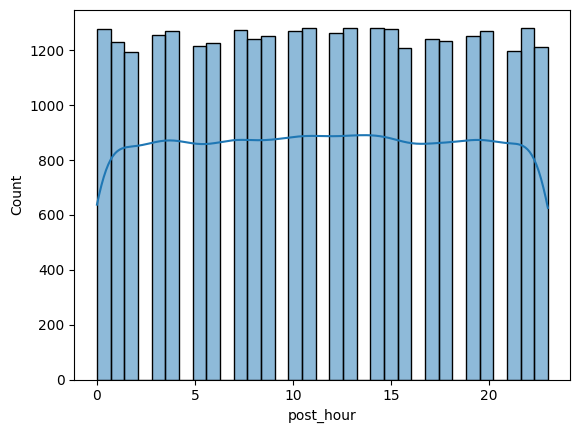

day_of_week


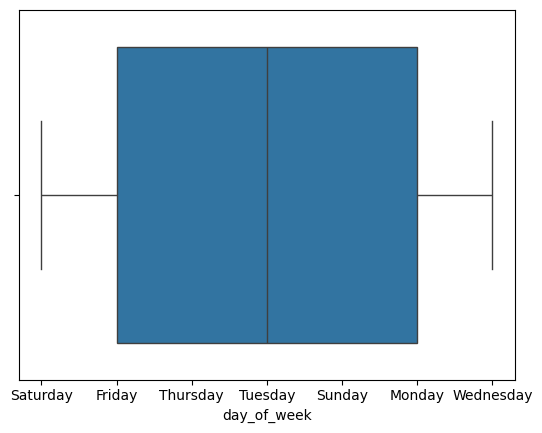

****************************************************************************************


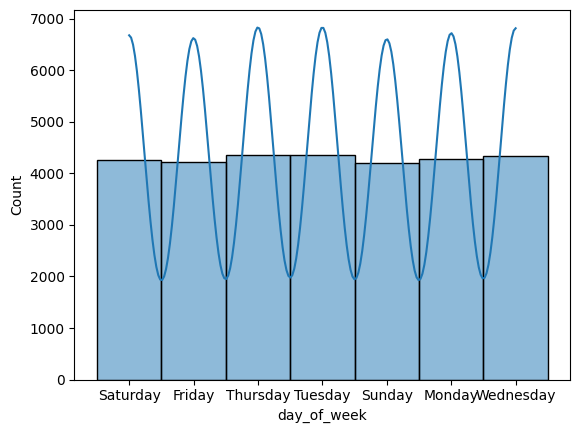

likes


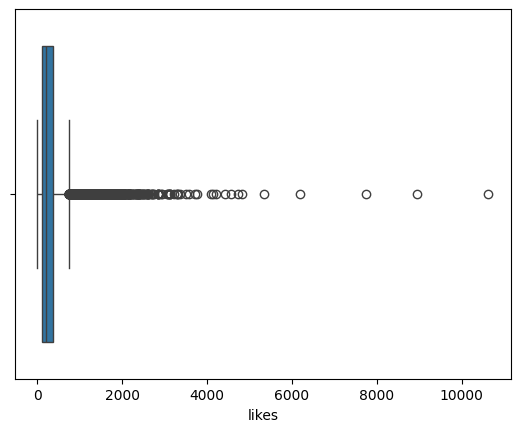

****************************************************************************************


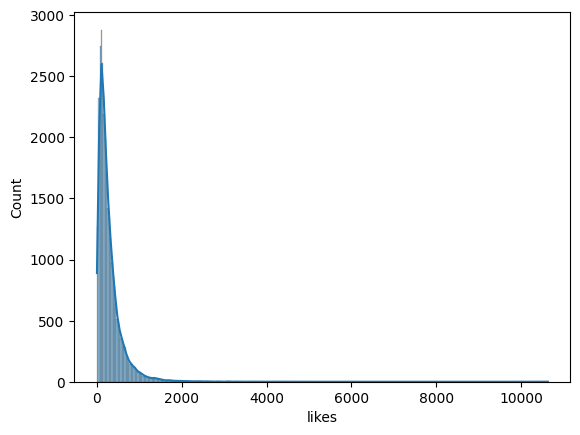

comments


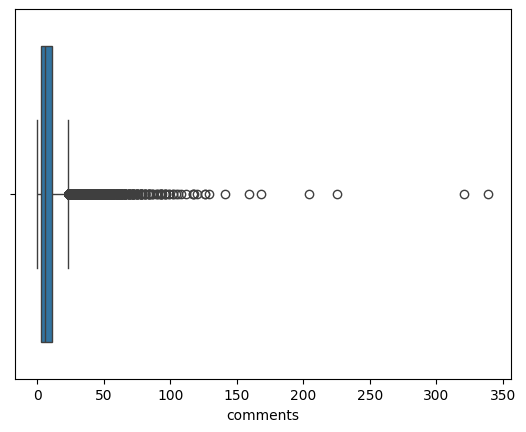

****************************************************************************************


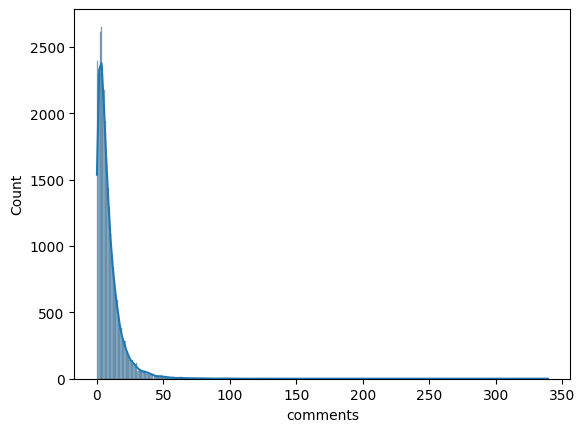

shares


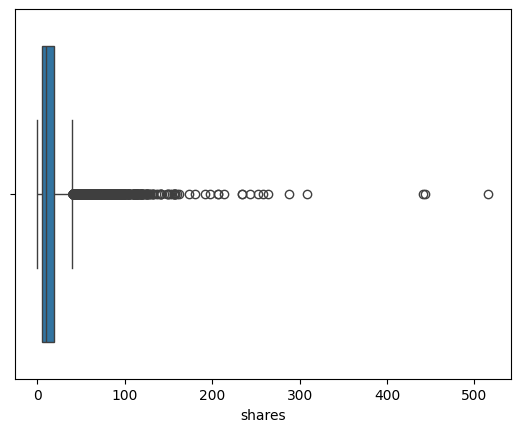

****************************************************************************************


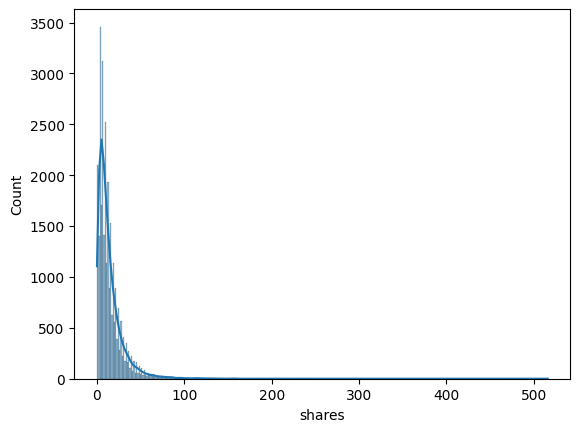

saves


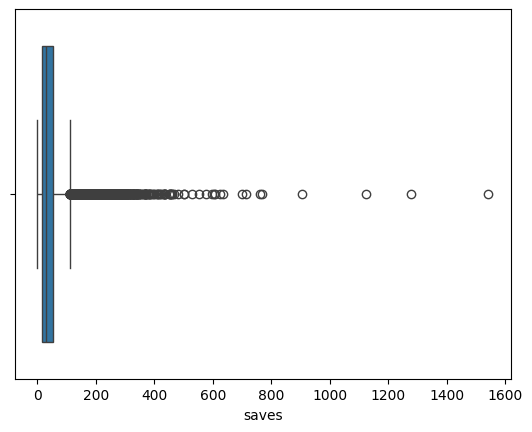

****************************************************************************************


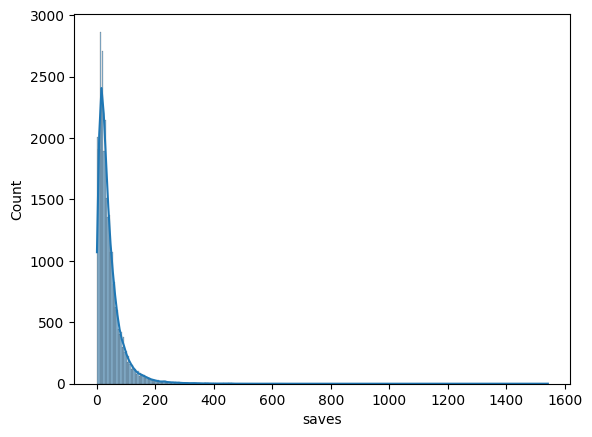

reach


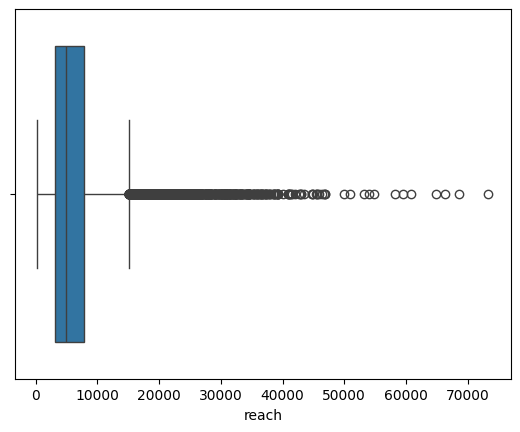

****************************************************************************************


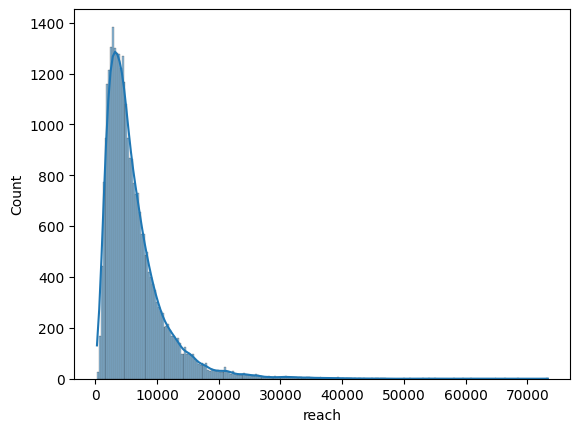

impressions


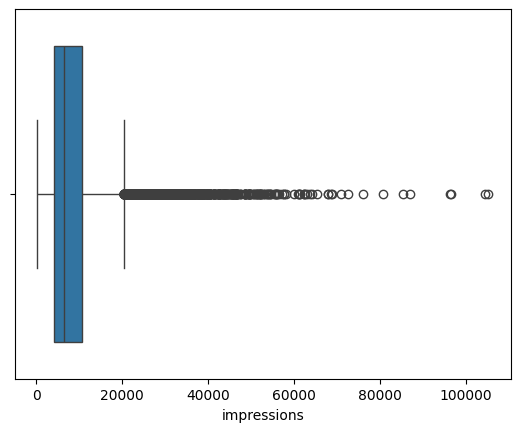

****************************************************************************************


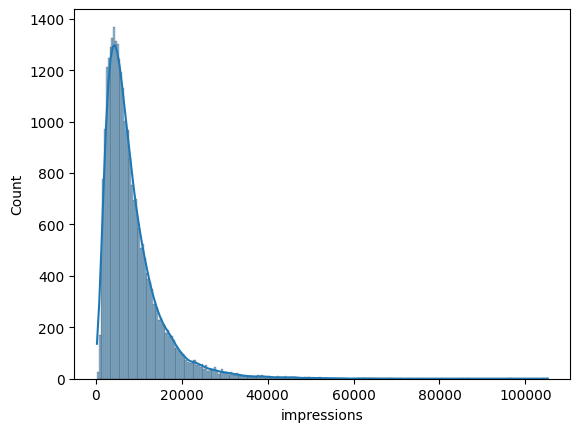

engagement_rate


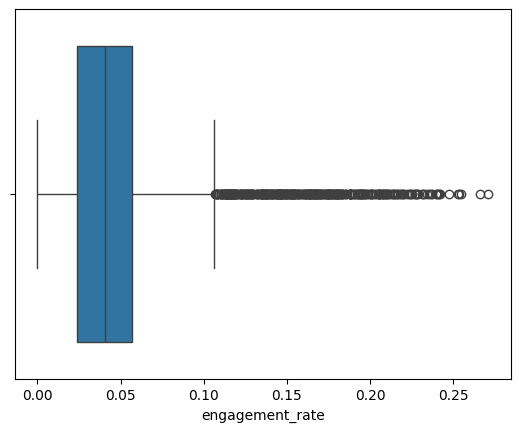

****************************************************************************************


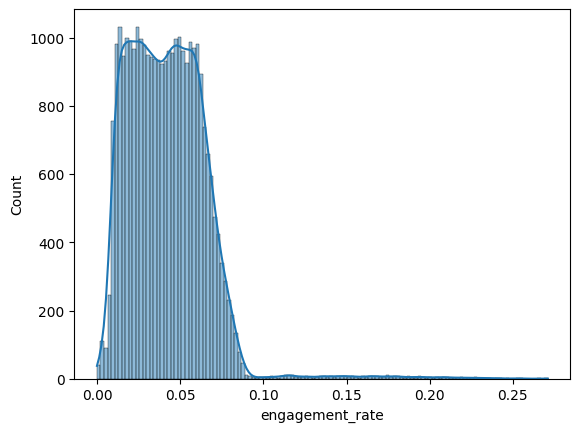

followers_gained


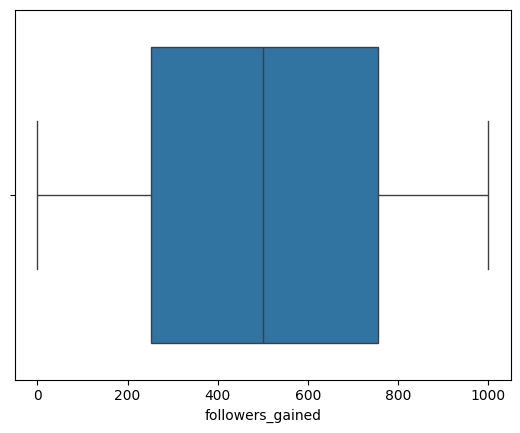

****************************************************************************************


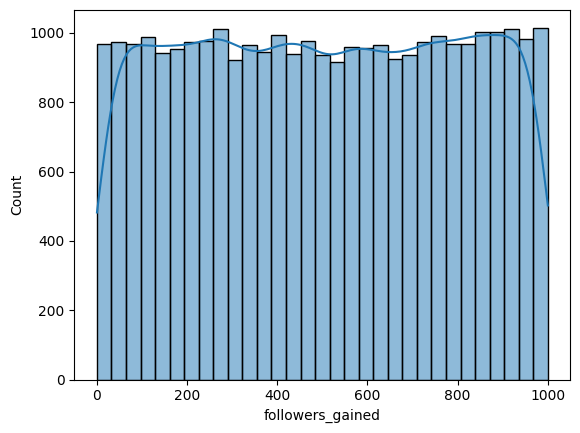

caption_length


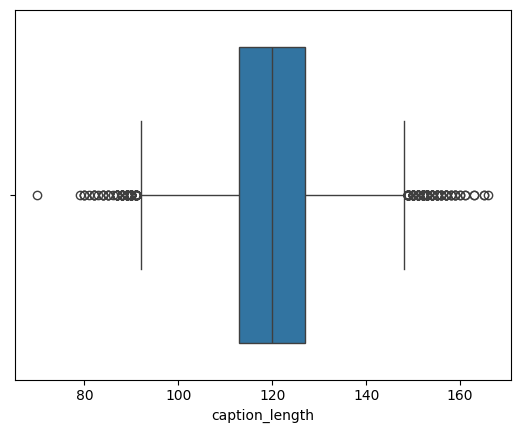

****************************************************************************************


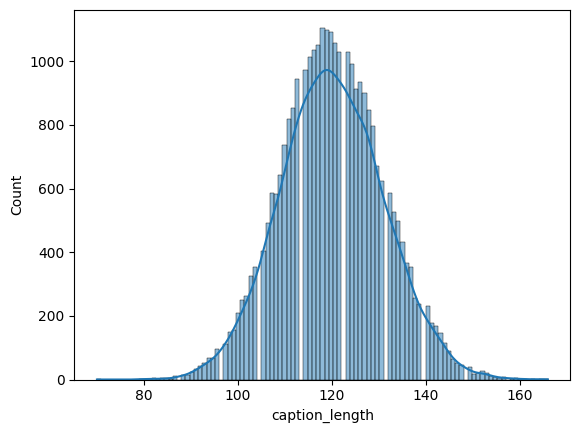

hashtags_count


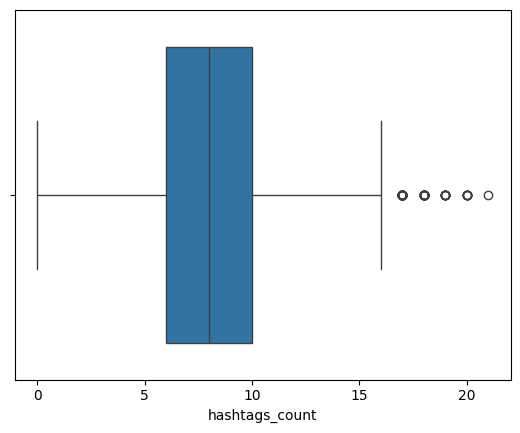

****************************************************************************************


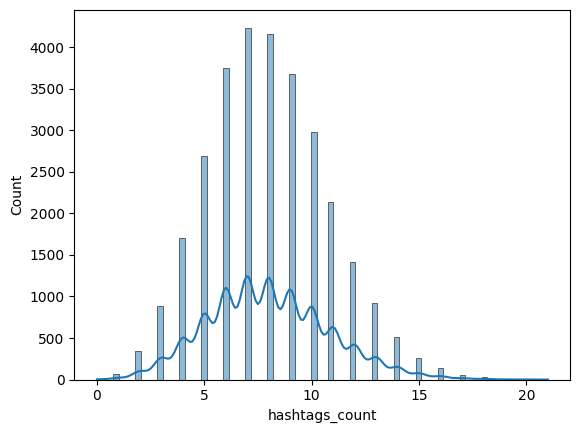

performance_bucket_label


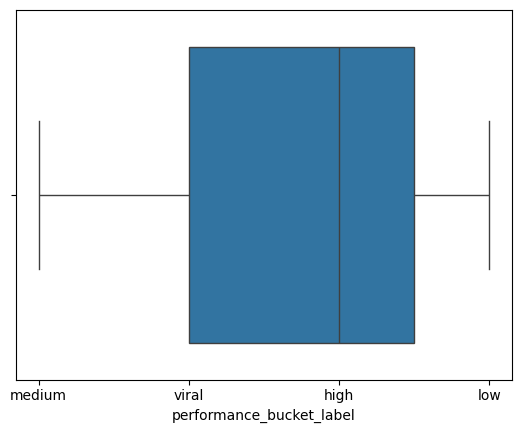

****************************************************************************************


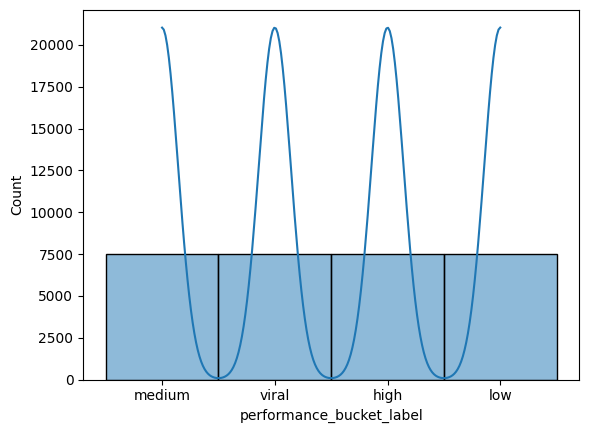

month


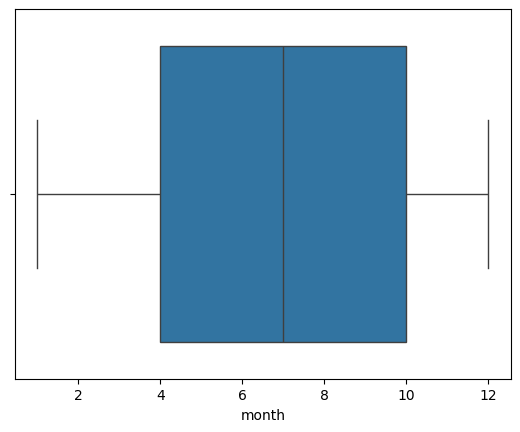

****************************************************************************************


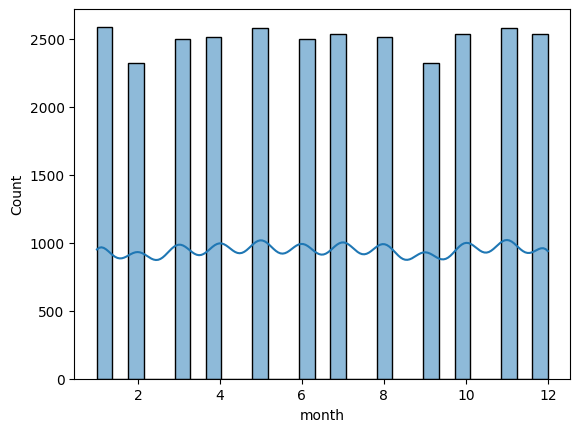

day


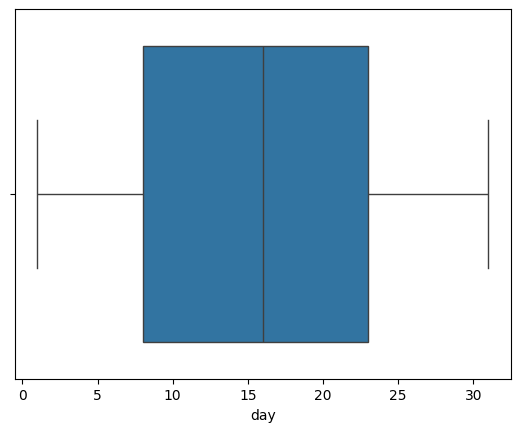

****************************************************************************************


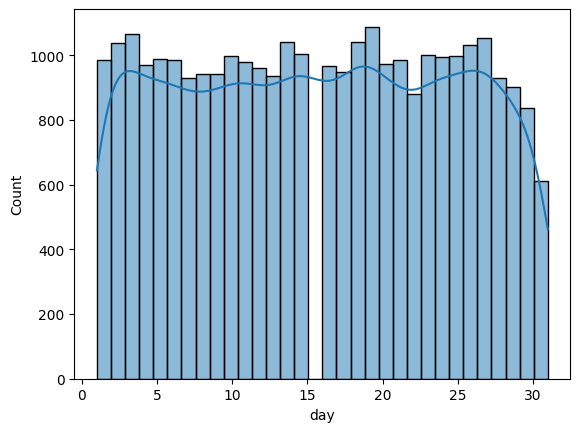

In [10]:
for i in df.columns: # for all cols
    if df[i].dtypes!=str: # for numeric cols
        sns.boxplot(data=df,x=i)
        print(i)
        show() # to plot separately of all cols
        print('****************************************************************************************')
        sns.histplot(data=df,x=i,kde=True)
        show()

engagement_rate vs account_id


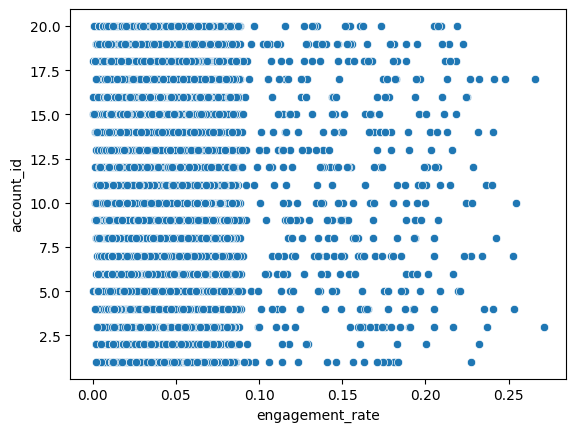

engagement_rate vs account_type


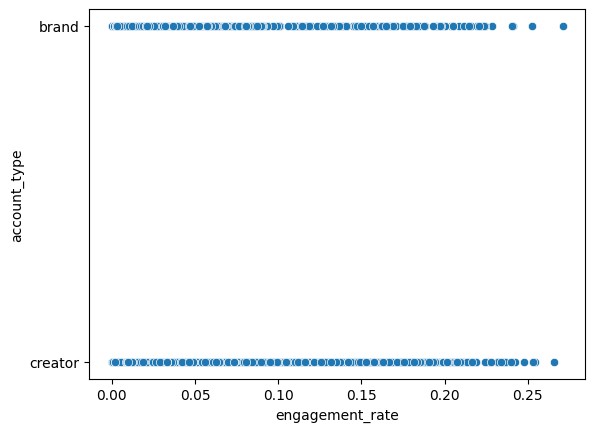

engagement_rate vs follower_count


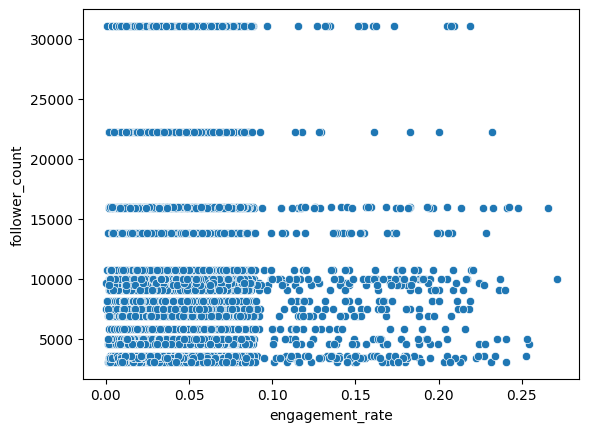

engagement_rate vs media_type


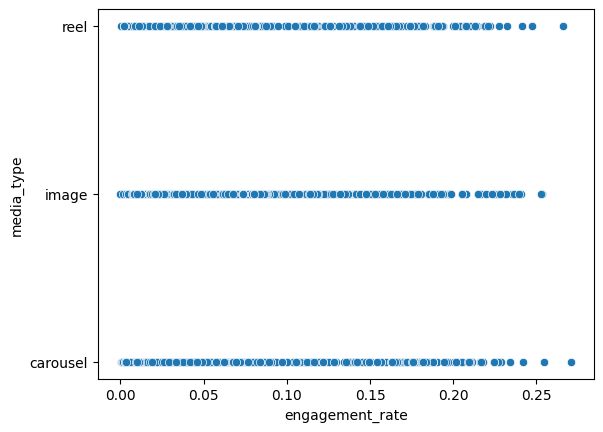

engagement_rate vs content_category


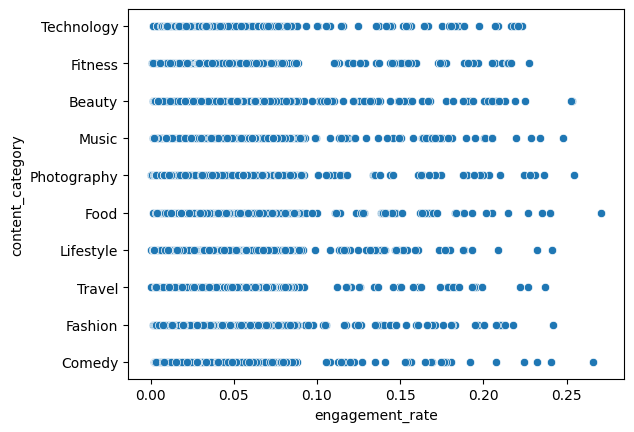

engagement_rate vs traffic_source


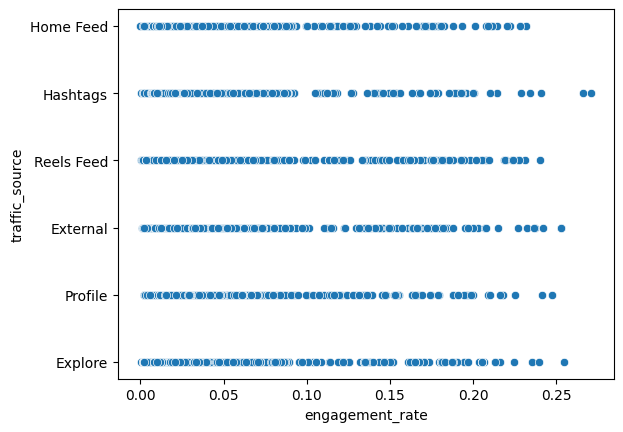

engagement_rate vs has_call_to_action


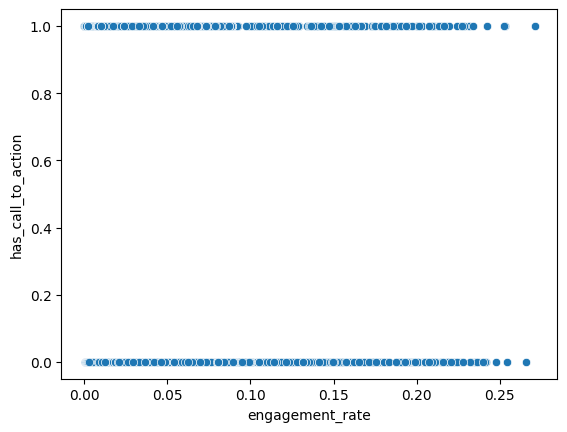

engagement_rate vs post_datetime


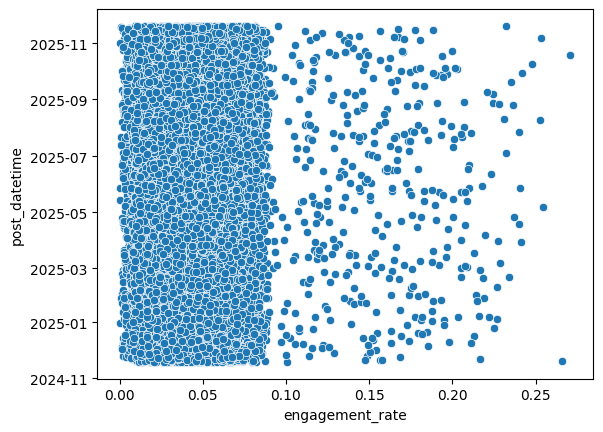

engagement_rate vs post_date


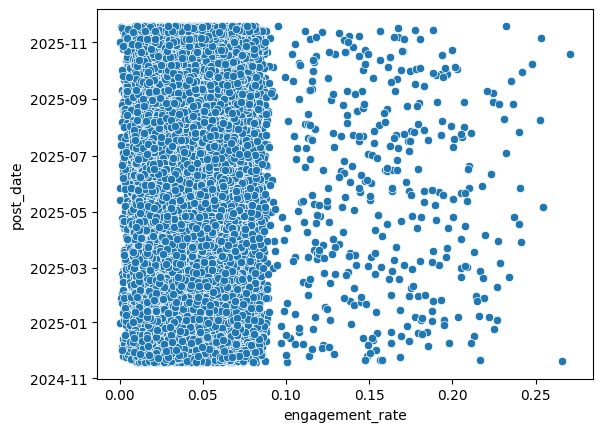

engagement_rate vs post_hour


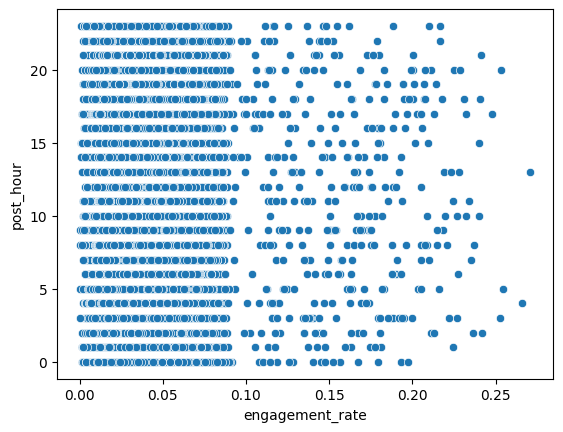

engagement_rate vs day_of_week


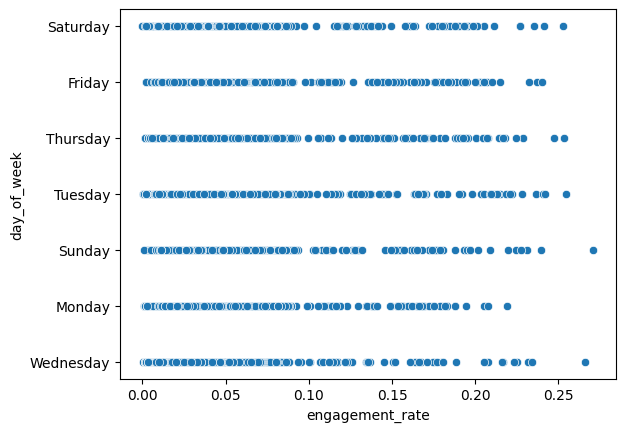

engagement_rate vs likes


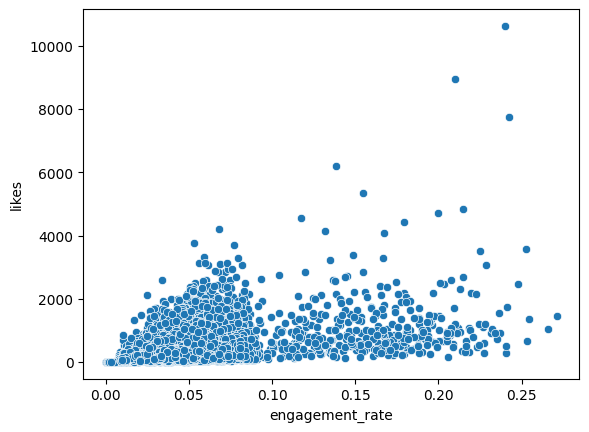

engagement_rate vs comments


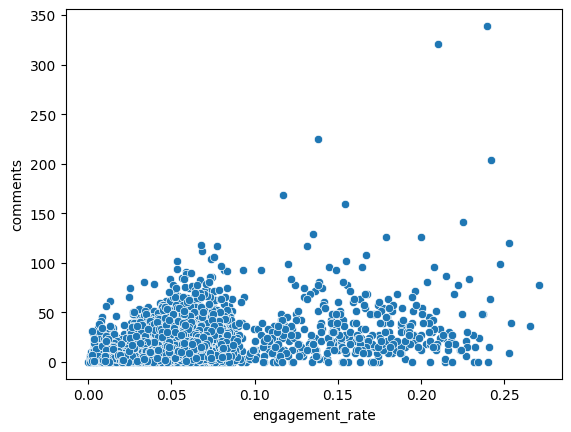

engagement_rate vs shares


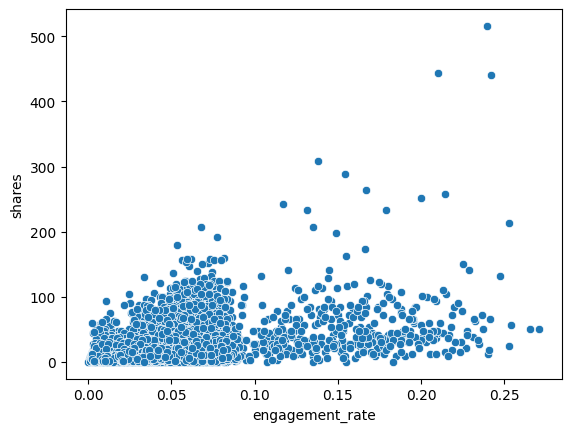

engagement_rate vs saves


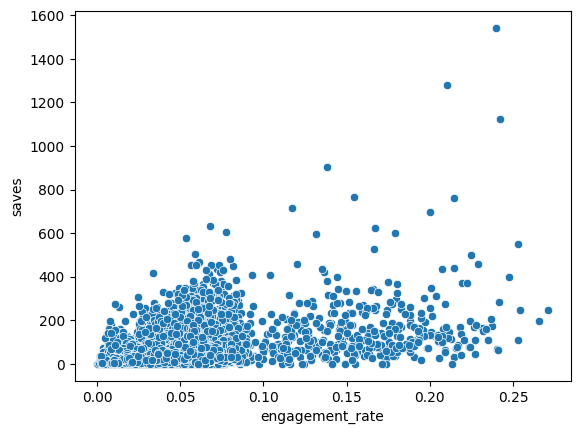

engagement_rate vs reach


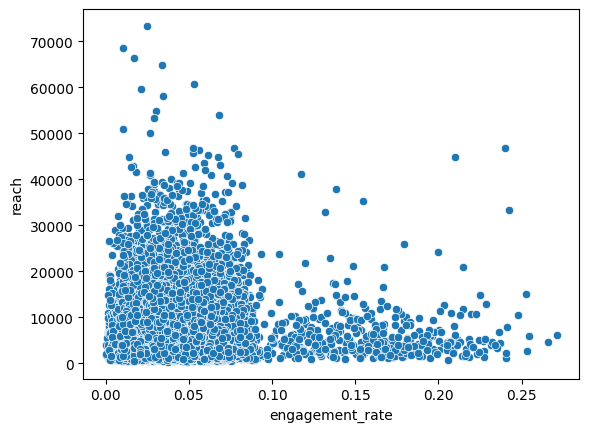

engagement_rate vs impressions


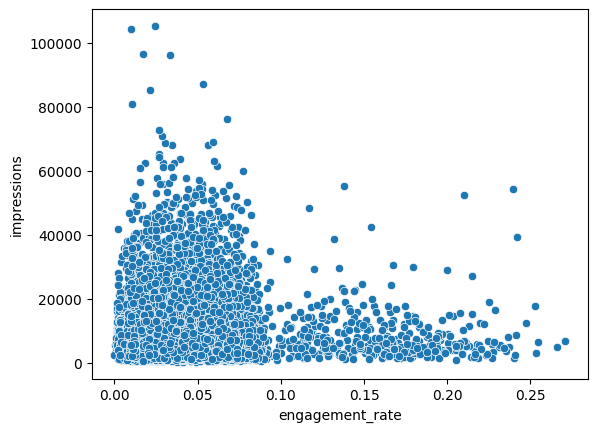

engagement_rate vs engagement_rate


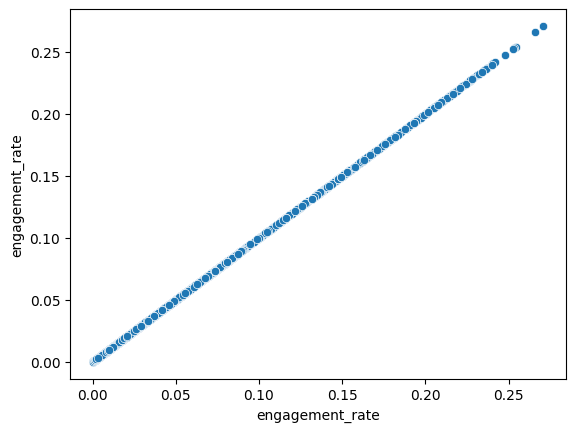

engagement_rate vs followers_gained


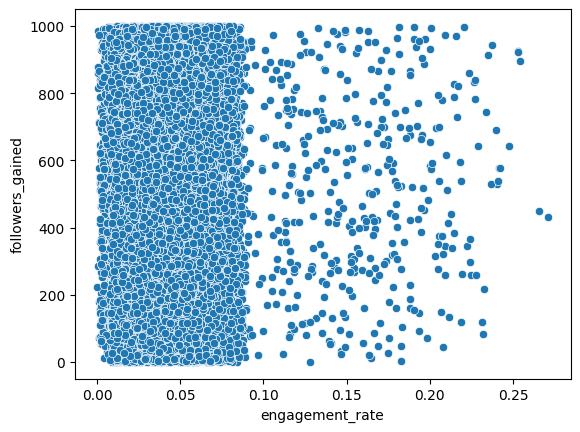

engagement_rate vs caption_length


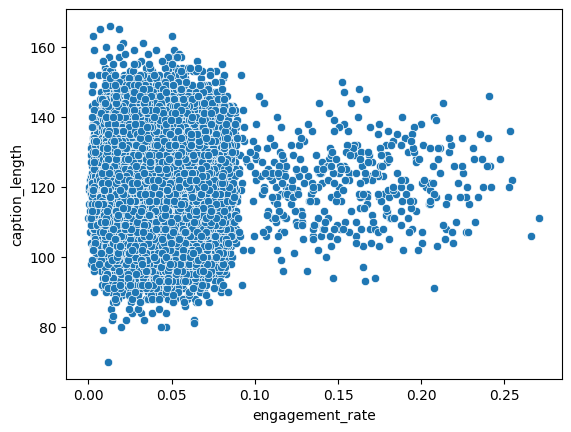

engagement_rate vs hashtags_count


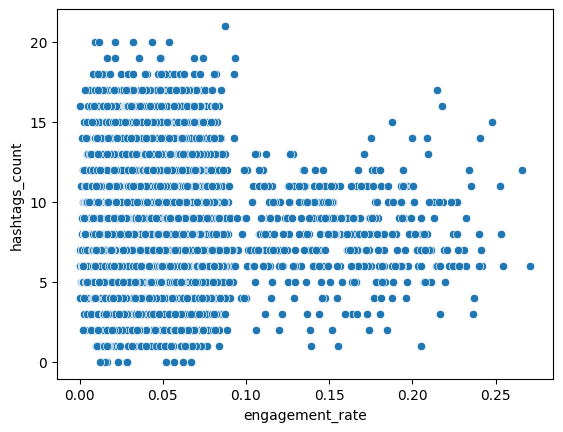

engagement_rate vs performance_bucket_label


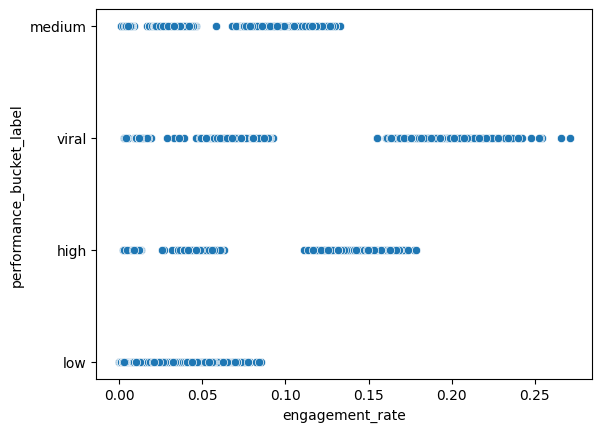

engagement_rate vs month


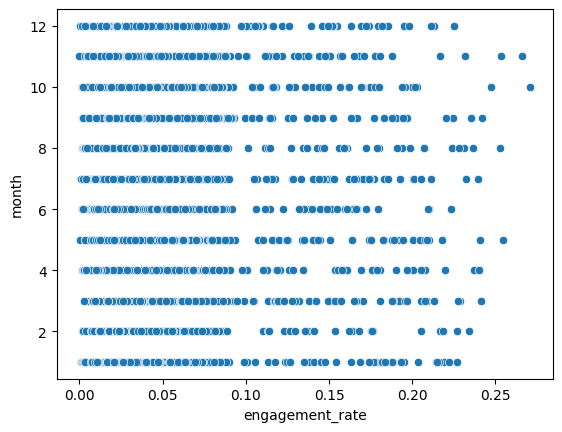

engagement_rate vs day


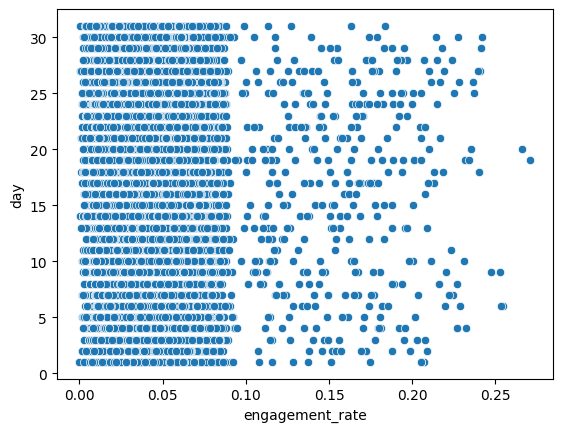

In [11]:
for i in df.columns:
    if df[i].dtypes!=str:
        print('engagement_rate vs',i)
        sns.scatterplot(data=df,x='engagement_rate',y=i)
        show()

In [14]:
df.corr(numeric_only=True)['engagement_rate'] \
    .drop('engagement_rate') \
    .sort_values(ascending=False)

likes                 0.506096
saves                 0.478121
shares                0.468681
comments              0.451598
day                   0.013244
account_id            0.009414
reach                 0.006187
month                 0.003030
followers_gained      0.000509
caption_length        0.000497
hashtags_count       -0.001246
follower_count       -0.005620
has_call_to_action   -0.007044
post_hour            -0.007065
impressions          -0.020682
Name: engagement_rate, dtype: float64

In [15]:
cols_to_drop=['likes', 'comments', 'shares', 'saves',  # leakage
    'account_id'  ]

In [16]:
cols_to_drop.append('engagement_rate')

In [17]:
x=df.drop(labels=cols_to_drop,axis=1) # all cols will store in x except dropped cols
y=df[['engagement_rate']]

In [18]:
x.isna().sum()

account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
reach                       0
impressions                 0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
month                       0
day                         0
dtype: int64

In [19]:
cat=[]
num=[]
for i in x.columns:
    if x[i].dtypes==object:
        cat.append(i)
    else:
        num.append(i)
xcat=x[cat]
xnum=x[num]

In [20]:
# Drop datetime
df = df.drop(columns=['post_datetime', 'post_date'],errors='ignore')

# Separate
xnum = df.select_dtypes(include=['int64', 'float64', 'int32'])
xcat = df.select_dtypes(include=['object'])

# Scale numeric
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
xnum_scaled = pd.DataFrame(ss.fit_transform(xnum), columns=xnum.columns)

# Encode categorical
xcat_encoded = pd.get_dummies(xcat, drop_first=True)

# Combine
final_df = pd.concat([xnum_scaled, xcat_encoded], axis=1)


/tmp/ipykernel_39428/4067940670.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  xcat = df.select_dtypes(include=['object'])


In [21]:
x=xnum.join(xcat)

In [22]:
x

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,...,caption_length,hashtags_count,month,day,account_type,media_type,content_category,traffic_source,day_of_week,performance_bucket_label
0,7,3551,1,6,194,5,7,34,4327,6230,...,100,7,11,30,brand,reel,Technology,Home Feed,Saturday,medium
1,20,31095,1,15,449,10,21,68,7451,8268,...,122,5,8,15,creator,image,Fitness,Hashtags,Friday,viral
2,15,8167,0,16,114,2,1,22,1639,2616,...,115,8,9,11,brand,reel,Beauty,Reels Feed,Thursday,high
3,11,9044,0,3,91,0,7,0,2877,3171,...,115,7,9,18,creator,carousel,Music,External,Thursday,medium
4,8,15986,0,9,154,8,5,21,5350,8503,...,112,9,3,21,creator,reel,Technology,Profile,Friday,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,5,10739,0,10,0,1,2,5,1564,2493,...,127,8,12,18,brand,carousel,Travel,Reels Feed,Wednesday,low
29995,3,10018,0,15,42,2,1,7,2042,2492,...,114,12,5,5,brand,image,Beauty,Hashtags,Monday,low
29996,18,7486,1,10,335,10,16,59,5887,7528,...,115,4,5,26,creator,image,Photography,Explore,Monday,high
29997,6,10034,1,19,188,3,0,19,5372,6312,...,124,4,8,2,creator,carousel,Technology,Explore,Saturday,medium


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)

In [36]:
from sklearn.ensemble import RandomForestClassifier


In [41]:
rfc= RandomForestClassifier()

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Drop unwanted columns
df = df.drop(columns=[
    'account_id',
    'likes', 'comments', 'shares', 'saves'  # avoid leakage
], errors='ignore')

# 2. Define target
y = df['performance_bucket_label']

# 3. Define features
X = df.drop(columns=['performance_bucket_label'])

# 4. Convert all categorical to numeric
x_final = pd.get_dummies(X, drop_first=True)

# 5. Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x_final, y, test_size=0.2, random_state=42
)

# 6. Train model
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [44]:
print(type(X))

<class 'pandas.DataFrame'>


In [45]:
from sklearn.metrics import accuracy_score

y_pred = rfc.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8391666666666666


In [46]:
tr_pred = rfc.predict(x_train)
ts_pred = rfc.predict(x_test)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Train Accuracy:", accuracy_score(y_train, tr_pred))
print("Test Accuracy:", accuracy_score(y_test, ts_pred))

print("\nClassification Report:\n", classification_report(y_test, ts_pred))

Train Accuracy: 1.0
Test Accuracy: 0.8391666666666666

Classification Report:
               precision    recall  f1-score   support

        high       0.84      0.79      0.81      1449
         low       0.89      0.87      0.88      1545
      medium       0.86      0.78      0.82      1510
       viral       0.78      0.92      0.84      1496

    accuracy                           0.84      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.84      0.84      0.84      6000

